# Phase 3 — Models

Two tracks, same walk-forward validation on pre-holdout months:
- **Track A — outright forecast.** Monthly CPI / core CPI / core PCE from FSBI, macro and own lags, with no nowcast as an input. Answers whether FSBI predicts inflation.
- **Track B — trading model.** Predicts the surprise vs the Cleveland nowcast on FSBI day. Answers whether FSBI adds anything the market doesn't already have.



In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from dotenv import load_dotenv
from fredapi import Fred
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
load_dotenv()
fred = Fred(api_key=os.environ["FRED_API_KEY"])
data = pd.read_csv("data/processed/integrated_monthly.csv", index_col="date", parse_dates=True)

KEYS = ["cpi", "core_cpi", "core_pce"]
HOLDOUT_START = pd.Timestamp("2025-03-01")
COVID = ("2020-03-01", "2021-06-01")
FSBI_DAY = 6
MIN_TRAIN = 24
rmse = lambda e: np.sqrt(np.mean(np.square(e)))

In [2]:
trade_day = data.index + pd.DateOffset(months=1, days=FSBI_DAY - 1)

def as_known(series_id, kind):
    """Latest MoM change published by each trade day, using the vintage available then."""
    v = fred.get_series_all_releases(series_id, realtime_start="2017-01-01")
    v["value"] = pd.to_numeric(v["value"], errors="coerce")
    out = []
    for day in trade_day:
        snap = v[v.realtime_start <= day].sort_values("realtime_start").groupby("date").value.last().dropna()
        out.append((snap.iloc[-1] / snap.iloc[-2] - 1) * 100 if kind == "pct" else snap.iloc[-1] - snap.iloc[-2])
    return pd.Series(out, index=data.index)

ALFRED = {
    # CPI and PCE prices
    "CPIAUCSL": ("cpi", "pct"), "CPILFESL": ("core_cpi", "pct"), "PCEPI": ("pce_price", "pct"),
    "PCEPILFE": ("core_pce", "pct"), "CUSR0000SAH1": ("shelter", "pct"), "CUSR0000SETA02": ("used_cars", "pct"),
    "CUSR0000SEFV": ("food_away", "pct"), "CUSR0000SAF11": ("food_home", "pct"), "CPIAPPSL": ("apparel", "pct"),
    "CUSR0000SETB01": ("cpi_gasoline", "pct"),
    # spending and income
    "RSAFS": ("retail_sales", "pct"), "RSFSXMV": ("retail_ex_auto", "pct"), "PCE": ("pce_spending", "pct"),
    "PCEDG": ("pce_durables", "pct"), "PCEND": ("pce_nondurables", "pct"), "PCES": ("pce_services", "pct"),
    "DSPIC96": ("real_income", "pct"), "PSAVERT": ("savings_rate", "diff"),
    # labour, activity, surveys
    "PAYEMS": ("payrolls", "pct"), "UNRATE": ("unemployment", "diff"), "INDPRO": ("industrial_prod", "pct"),
    "HOUST": ("housing_starts", "pct"), "UMCSENT": ("sentiment", "diff"), "MICH": ("inflation_expect", "diff"),
}
MARKET = {"oil": "pct", "fed_funds": "diff", "treasury_2y": "diff", "treasury_10y": "diff", "dgs5": "diff",
          "dgs3mo": "diff", "dgs5_minus_dgs3mo": "diff", "breakeven_10y": "diff", "vix": "diff", "dollar": "pct"}

macro = pd.DataFrame({f"m_{name}": as_known(sid, kind) for sid, (name, kind) in ALFRED.items()})
for col, kind in MARKET.items():
    macro[f"m_{col}"] = data[col].pct_change(fill_method=None) * 100 if kind == "pct" else data[col].diff()
gas = fred.get_series("GASREGW", observation_start="2017-01-01").resample("MS").mean()  # weekly retail gasoline
macro["m_gas_retail"] = (gas.pct_change() * 100).reindex(data.index)
macro.loc[:HOLDOUT_START].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
m_cpi,75.0,0.31,0.33,-0.80,0.11,0.31,0.44,1.32
m_core_cpi,75.0,0.30,0.22,-0.45,0.16,0.28,0.40,0.92
m_pce_price,75.0,0.25,0.23,-0.47,0.10,0.25,0.36,0.95
m_core_pce,75.0,0.24,0.17,-0.39,0.15,0.25,0.34,0.66
m_shelter,75.0,0.37,0.19,-0.03,0.25,0.37,0.50,0.80
m_used_cars,75.0,0.43,2.68,-3.80,-1.20,-0.25,1.40,10.49
m_food_away,75.0,0.41,0.21,0.05,0.26,0.37,0.53,0.95
m_food_home,75.0,0.35,0.53,-1.10,0.05,0.27,0.49,2.58
m_apparel,75.0,0.07,1.05,-4.69,-0.36,0.23,0.66,2.21
m_cpi_gasoline,75.0,0.40,5.84,-20.63,-3.41,0.17,3.35,18.30


## 2. Toolkit

Every model fits `y` and the forecast is `base + prediction` (`base` = 0 in Track A, the nowcast in Track B). Lasso penalty and XGBoost depth/trees are tuned inside each training window with a 4-fold time-series split. Lasso keeps at most 5 inputs.

In [3]:
FSBI = ["fsbi_sales_sa_log_mom", "fsbi_txn_sa_log_mom", "fsbi_ticket_index_sa_log_mom",
        "fsbi_sector_sales_breadth", "fsbi_sector_ticket_breadth", "fsbi_state_sales_breadth"]
FSBI_COLS = [c.removeprefix("fsbi_").removesuffix("_log_mom") for c in FSBI]
MACRO_COLS = list(macro.columns)
FSBI_SPARSE = ["sales_sa", "ticket_index_sa"]
inner = TimeSeriesSplit(n_splits=4)

def table(y, base, extra, end=HOLDOUT_START):
    tbl = pd.DataFrame({"y": y, "base": base}).join(pd.DataFrame(extra))
    tbl = tbl.join(data[FSBI].set_axis(FSBI_COLS, axis=1)).join(macro)
    covid = tbl.index.to_series().between(*COVID)
    return tbl[~covid & (tbl.index < end)].dropna()

def cv_mse(make, X, y):
    errs = []
    for tr, te in inner.split(X):
        m = make().fit(X.iloc[tr], y.iloc[tr])
        errs.append(np.mean((y.iloc[te] - m.predict(X.iloc[te])) ** 2))
    return np.mean(errs)

def column(col):  # reference forecasts that aren't fitted
    return lambda train, test: (test[col].iloc[0] - test.base.iloc[0], {})

def ols(cols):
    return lambda train, test: (LinearRegression().fit(train[cols], train.y).predict(test[cols])[0], {})

def lasso(cols, max_inputs=5, alphas=np.logspace(-3.5, -0.5, 30)):
    make = lambda a: make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=50_000))
    def fit_predict(train, test):
        sparse_enough = [a for a in alphas if np.count_nonzero(make(a).fit(train[cols], train.y)[-1].coef_) <= max_inputs]
        a = min(sparse_enough, key=lambda a: cv_mse(lambda: make(a), train[cols], train.y))
        m = make(a).fit(train[cols], train.y)
        coef = pd.Series(m[-1].coef_, index=cols)
        return m.predict(test[cols])[0], {"selected": list(coef[coef != 0].index)}
    return fit_predict

GRID = [{"max_depth": d, "n_estimators": n} for d in (1, 2) for n in (50, 150)]
def xgb(cols):
    make = lambda p: XGBRegressor(learning_rate=0.05, subsample=0.8, min_child_weight=3, random_state=0, n_jobs=1, **p)
    def fit_predict(train, test):
        p = min(GRID, key=lambda p: cv_mse(lambda: make(p), train[cols], train.y))
        return make(p).fit(train[cols], train.y).predict(test[cols])[0], {}
    return fit_predict

def rf(cols):
    make = lambda: RandomForestRegressor(n_estimators=300, min_samples_leaf=5, max_features=0.5, random_state=0)
    return lambda train, test: (make().fit(train[cols], train.y).predict(test[cols])[0], {})

def arimax(cols, order=(1, 0, 1)):
    def fit_predict(train, test):
        idx = pd.date_range(train.index[0], test.index[0], freq="MS")  # COVID gap and test month left missing
        X = pd.concat([train, test])[cols].reindex(idx).fillna(0) if cols else None
        res = SARIMAX(train.y.reindex(idx), exog=X, order=order, trend="c").fit(disp=False)
        return res.fittedvalues.iloc[-1], {}
    return fit_predict

def walk_forward(tbl, models, start=MIN_TRAIN):
    rows, picks = [], []
    for i in range(start, len(tbl)):
        train, test = tbl.iloc[:i], tbl.iloc[[i]]
        row = {"date": tbl.index[i], "actual": test.actual.iloc[0]}
        for name, model in models.items():
            pred, extra = model(train, test)
            row[name] = test.base.iloc[0] + pred
            picks += [{"model": name, "feature": f} for f in extra.get("selected", [])]
        rows.append(row)
    return pd.DataFrame(rows).set_index("date"), pd.DataFrame(picks, columns=["model", "feature"])

def score(f, models, refs):
    """RMSE/MAE, R² relative to each reference forecast, 0.1-bucket hit rate, Diebold–Mariano p vs the first reference."""
    e_ref = {r: f.actual - f[r] for r in refs}
    out = {}
    for m in models:
        e = f.actual - f[m]
        d = e**2 - e_ref[refs[0]]**2
        out[m] = {"RMSE": rmse(e), "MAE": e.abs().mean(),
                  **{f"R2_vs_{r}": 1 - (e**2).sum() / (e_ref[r]**2).sum() for r in refs},
                  "bucket_hit": (f[m].round(1) == f.actual.round(1)).mean(),
                  f"DM_p_vs_{refs[0]}": np.nan if m in refs else
                      sm.OLS(d, np.ones(len(d))).fit(cov_type="HAC", cov_kwds={"maxlags": 3}).pvalues.iloc[0]}
    return pd.DataFrame(out).T

def heatmap(scores, col, keys, title):
    plt.figure(figsize=(7, 0.45 * scores.index.get_level_values(1).nunique() + 1))
    sns.heatmap(scores[col].unstack(0)[keys].loc[scores.loc[keys[0]].index], annot=True, fmt=".2f",
                cmap="RdYlGn", center=0, vmin=-0.3, vmax=0.3, cbar=False)
    plt.title(title)

## 3. Track A — outright forecast

Target: first-print MoM. Inputs: last two months' prints, FSBI, macro. The nowcast is only a reference line.

Compares performace using ablation setup (adding predictor one at a time in order to compare performance). Adds lagged value, macro data, and FSBI data incrementally.

In [4]:
A_KEYS = ["cpi", "core_cpi", "core_pce"]
MACRO_CORE = ["m_shelter", "m_used_cars", "m_food_away"]
LAGS = ["y1", "y2"]
WIDE_A = LAGS + FSBI_COLS + MACRO_COLS

def table_a(k, end=HOLDOUT_START):
    fp = data[f"clev_{k}_first_print"]
    return table(fp, 0.0, {"actual": fp, "nowcast": data[f"clev_{k}_nowcast_fsbi"], "y1": fp.shift(1), "y2": fp.shift(2)}, end)

MODELS_A = {
    "Nowcast": column("nowcast"),
    "Last month": column("y1"),
    "A0 AR(2)": ols(LAGS),
    "A1 AR + macro": ols(LAGS + MACRO_CORE),
    "A2 AR + FSBI": ols(LAGS + FSBI_SPARSE),
    "A3 AR + macro + FSBI": ols(LAGS + MACRO_CORE + FSBI_SPARSE),
    "ARIMA(1,0,1)": arimax([]),
    "ARIMAX(1,0,1) + FSBI": arimax(FSBI_SPARSE),
    "Lasso (wide, ≤5)": lasso(WIDE_A),
    "Random forest (wide)": rf(WIDE_A),
    "XGBoost (wide)": xgb(WIDE_A),
}
runs_a = {k: walk_forward(table_a(k), MODELS_A) for k in A_KEYS}
scores_a = pd.concat({k: score(f, MODELS_A, refs=["A0 AR(2)", "Nowcast"]) for k, (f, _) in runs_a.items()})
scores_a.round(3)

RMSE    MAE  R2_vs_A0 AR(2)  R2_vs_Nowcast  \
cpi      Nowcast               0.159  0.123           0.635          0.000   
         Last month            0.325  0.211          -0.527         -3.181   
         A0 AR(2)              0.263  0.181           0.000         -1.738   
         A1 AR + macro         0.337  0.232          -0.642         -3.495   
         A2 AR + FSBI          0.273  0.202          -0.083         -1.964   
         A3 AR + macro + FSBI  0.352  0.238          -0.799         -3.926   
         ARIMA(1,0,1)          0.262  0.181           0.007         -1.719   
         ARIMAX(1,0,1) + FSBI  0.276  0.214          -0.101         -2.014   
         Lasso (wide, ≤5)      0.159  0.124           0.634         -0.003   
         Random forest (wide)  0.199  0.159           0.428         -0.565   
         XGBoost (wide)        0.213  0.175           0.344         -0.796   
core_cpi Nowcast               0.129  0.097          -0.196          0.000   
         Last month            0.140  0.102          -0.395         -0.166   
         A0 AR(2)              0.118  0.086           0.000          0.164   
         A1 AR + macro         0.145  0.105          -0.509         -0.261   
         A2 AR + FSBI          0.114  0.088           0.071          0.223   
         A3 AR + macro + FSBI  0.136  0.099          -0.334         -0.115   
         ARIMA(1,0,1)          0.128  0.095          -0.173          0.020   
         ARIMAX(1,0,1) + FSBI  0.131  0.099          -0.235         -0.033   
         Lasso (wide, ≤5)      0.113  0.096           0.081          0.231   
         Random forest (wide)  0.110  0.085           0.132          0.274   
         XGBoost (wide)        0.125  0.091          -0.115          0.068   
core_pce Nowcast               0.137  0.114           0.215          0.000   
         Last month            0.179  0.138          -0.349         -0.719   
         A0 AR(2)              0.154  0.119           0.000         -0.274   
         A1 AR + macro         0.166  0.128          -0.161         -0.479   
         A2 AR + FSBI          0.155  0.116          -0.004         -0.279   
         A3 AR + macro + FSBI  0.162  0.126          -0.105         -0.407   
         ARIMA(1,0,1)          0.140  0.108           0.173         -0.053   
         ARIMAX(1,0,1) + FSBI  0.147  0.117           0.089         -0.161   
         Lasso (wide, ≤5)      0.143  0.107           0.142         -0.092   
         Random forest (wide)  0.132  0.100           0.271          0.072   
         XGBoost (wide)        0.141  0.102           0.168         -0.060   

                               bucket_hit  DM_p_vs_A0 AR(2)  
cpi      Nowcast                    0.312               NaN  
         Last month                 0.219             0.117  
         A0 AR(2)                   0.188               NaN  
         A1 AR + macro              0.219             0.127  
         A2 AR + FSBI               0.156             0.569  
         A3 AR + macro + FSBI       0.125             0.198  
         ARIMA(1,0,1)               0.312             0.920  
         ARIMAX(1,0,1) + FSBI       0.156             0.451  
         Lasso (wide, ≤5)           0.156             0.066  
         Random forest (wide)       0.156             0.119  
         XGBoost (wide)             0.125             0.180  
core_cpi Nowcast                    0.281               NaN  
         Last month                 0.344             0.042  
         A0 AR(2)                   0.500               NaN  
         A1 AR + macro              0.375             0.090  
         A2 AR + FSBI               0.375             0.518  
         A3 AR + macro + FSBI       0.375             0.093  
         ARIMA(1,0,1)               0.406             0.103  
         ARIMAX(1,0,1) + FSBI       0.406             0.150  
         Lasso (wide, ≤5)           0.312             0.779  
         Random forest (wide)       0.219             0.694  
         XGBoos

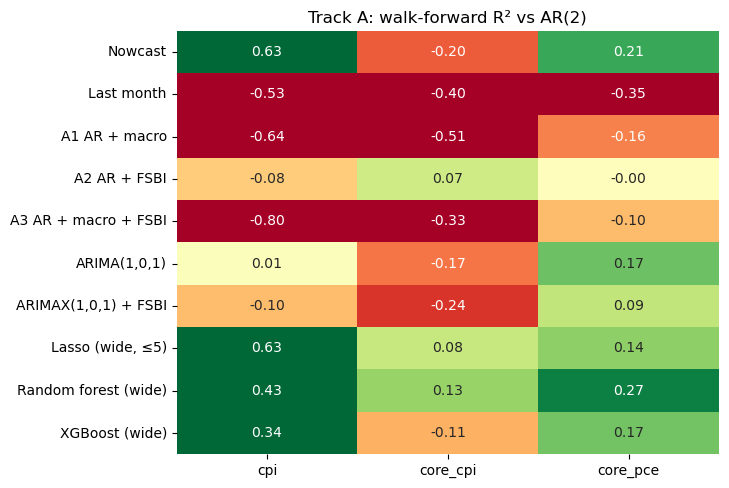

In [5]:
heatmap(scores_a.drop(index=["A0 AR(2)"], level=1), "R2_vs_A0 AR(2)", A_KEYS, "Track A: walk-forward R² vs AR(2)")

## 4. Track B — trading model

Target: surprise vs the FSBI-day nowcast (CPI and core CPI; core PCE dropped). Sparse OLS is the primary model; 

In [6]:
B_KEYS = ["cpi", "core_cpi"]
SPARSE_B = ["nowcast", "surprise_lag1"] + FSBI_SPARSE
WIDE_B = ["nowcast", "surprise_lag1"] + FSBI_COLS + MACRO_COLS

def table_b(k, end=HOLDOUT_START):
    s, nc = data[f"clev_{k}_surprise"], data[f"clev_{k}_nowcast_fsbi"]
    return table(s, nc, {"actual": data[f"clev_{k}_first_print"], "nowcast": nc, "surprise_lag1": s.shift(1)}, end)

MODELS_B = {
    "Nowcast": column("nowcast"),
    "AR(1) surprise": ols(["surprise_lag1"]),
    "Sparse OLS (primary)": ols(SPARSE_B),
    "ARIMAX(1,0,1) (robustness)": arimax(FSBI_SPARSE),
    "Lasso (wide, ≤5)": lasso(WIDE_B),
}
runs_b = {k: walk_forward(table_b(k), MODELS_B) for k in B_KEYS}
scores_b = pd.concat({k: score(f, MODELS_B, refs=["Nowcast"]) for k, (f, _) in runs_b.items()})
scores_b.round(3)

RMSE    MAE  R2_vs_Nowcast  bucket_hit  \
cpi      Nowcast                     0.168  0.130          0.000       0.303   
         AR(1) surprise              0.160  0.116          0.091       0.303   
         Sparse OLS (primary)        0.158  0.119          0.113       0.242   
         ARIMAX(1,0,1) (robustness)  0.151  0.121          0.195       0.333   
         Lasso (wide, ≤5)            0.179  0.134         -0.141       0.303   
core_cpi Nowcast                     0.133  0.101          0.000       0.273   
         AR(1) surprise              0.125  0.090          0.114       0.394   
         Sparse OLS (primary)        0.117  0.091          0.222       0.273   
         ARIMAX(1,0,1) (robustness)  0.115  0.088          0.245       0.333   
         Lasso (wide, ≤5)            0.132  0.098          0.006       0.303   

                                     DM_p_vs_Nowcast  
cpi      Nowcast                                 NaN  
         AR(1) surprise                        0.539  
         Sparse OLS (primary)                  0.574  
         ARIMAX(1,0,1) (robustness)            0.151  
         Lasso (wide, ≤5)                      0.190  
core_cpi Nowcast                                 NaN  
         AR(1) surprise                        0.260  
         Sparse OLS (primary)                  0.136  
         ARIMAX(1,0,1) (robustness)            0.099  
         Lasso (wide, ≤5)                      0.913

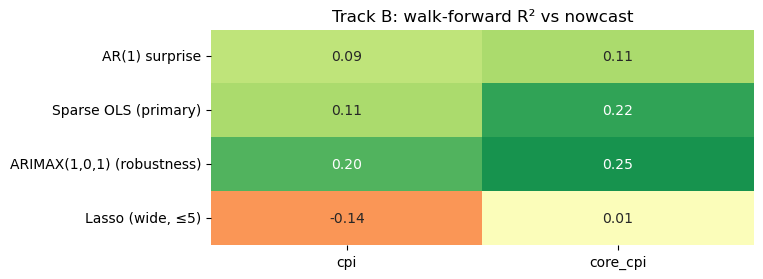

In [7]:
heatmap(scores_b.drop(index=["Nowcast"], level=1), "R2_vs_Nowcast", B_KEYS, "Track B: walk-forward R² vs nowcast")

Sparse OLS and ARIMAX beat the nowcast for CPI and core CPI; Lasso doesn't. Nothing is significant at 5% with 33 forecasts.

## 5. What Lasso picks

Share of walk-forward refits in which each feature was selected.

In [8]:
n_fc = {k: len(f) for k, (f, _) in runs_a.items()}
pd.concat({**{f"A {k}": p.feature.value_counts() / n_fc[k] for k, (_, p) in runs_a.items()},
           **{f"B {k}": p.feature.value_counts() / n_fc[k] for k, (_, p) in runs_b.items()}}, axis=1).fillna(0).round(2)

,A cpi,A core_cpi,A core_pce,B cpi,B core_cpi
feature,,,,,
m_food_home,1.00,0.94,0.97,0.66,0.00
m_oil,1.00,0.00,0.00,0.00,0.00
m_gas_retail,1.00,0.00,0.00,0.00,0.00
ticket_index_sa,0.75,0.34,0.78,0.41,0.00
m_core_cpi,0.34,0.78,0.66,0.00,0.00
m_dgs5,0.28,0.12,0.19,0.03,0.00
m_food_away,0.03,0.00,0.03,0.03,0.00
m_fed_funds,0.03,0.00,0.00,0.06,0.00
y1,0.00,0.84,0.03,0.00,0.00


## 6. Holdout

Run once, after the model and trading rules are locked. Set `RUN_HOLDOUT = True` only then.

In [9]:
RUN_HOLDOUT = False
if RUN_HOLDOUT:
    end = data.index[-1] + pd.DateOffset(days=1)
    for name, build, models, keys, refs in [("A", table_a, MODELS_A, A_KEYS, ["A0 AR(2)", "Nowcast"]),
                                             ("B", table_b, MODELS_B, B_KEYS, ["Nowcast"])]:
        out = {}
        for k in keys:
            full = build(k, end)
            out[k] = score(walk_forward(full, models, start=(full.index < HOLDOUT_START).sum())[0], models, refs)
        display(pd.concat(out).round(3))